# **Visualization of macrophage subset signatures in the spatial dataset**

## Imports

In [10]:
import os
import ast
import itertools
import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from scipy.stats import hypergeom, spearmanr, pearsonr, zscore
from statsmodels.stats.multitest import multipletests
from plotnine import *
import warnings
warnings.filterwarnings("ignore")

BASE_PATH = "/home/projects/nyosef/oier/Harreman_files/Slide_seq_lung"
SC_REF_PATH = os.path.join(BASE_PATH, 'sc_reference')
ADATA_PATH = os.path.join(BASE_PATH, 'h5ads')
DATA_PATH = os.path.join(BASE_PATH, 'data')
PLOTS_PATH = os.path.join(BASE_PATH, 'plots')

## CXCL10-Hi TAM signature score visualization on the spatial data

In [2]:
adata = ad.read_h5ad(os.path.join(ADATA_PATH, 'Slide_seq_lung_revision_macrophage_subset_visionpy_adata.h5ad'))

In [3]:
def _prettify_axis(ax, spatial=False):
    # Hide the right and top spines
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)
    # Only show ticks on the left and bottom spines
    ax.yaxis.set_ticks_position("left")
    ax.xaxis.set_ticks_position("bottom")
    if spatial:
        plt.xticks([])
        plt.yticks([])
        plt.xlabel("Spatial1")
        plt.ylabel("Spatial2")

In [4]:
def plot_signature(adata, scores, signature, coords_obsm_key, s, vmin, vmax, figsize, cmap, colorbar, swap_y_axis):

    if isinstance(adata.obsm[coords_obsm_key], pd.DataFrame):
        coords = adata.obsm[coords_obsm_key].values
    else:
        coords = adata.obsm[coords_obsm_key]
    
    # plt.figure(figsize=figsize)
    ax = plt.subplot(111)
    ax.set_aspect('equal', adjustable='box')
    _prettify_axis(ax, spatial=True)
    if swap_y_axis:
        plt.scatter(coords[:,0], -coords[:,1], c=scores[signature], cmap=cmap, s=s, vmin=vmin, vmax=vmax)
    else:
        plt.scatter(coords[:,0], coords[:,1], c=scores[signature], cmap=cmap, s=s, vmin=vmin, vmax=vmax)
    plt.title(f'{signature}')
    if colorbar:
        plt.colorbar()

In [43]:
def plot_signature_scores(
    adata,
    coords_obsm_key = None,
    signatures = None,
    sample_specific = False,
    s = None,
    vmin = None,
    vmax = None,
    figsize = (10,10),
    cmap = 'Reds',
    colorbar = True,
    swap_y_axis = False,
    save = False,
    show = False,
):
    
    if isinstance(vmin, str) and 'p' not in vmin:
        raise ValueError('"vmin" needs to be either a numeric value or a percentile: e.g. "p5".')
    if isinstance(vmax, str) and 'p' not in vmax:
        raise ValueError('"vmax" needs to be either a numeric value or a percentile: e.g. "p95".')
    
    if sample_specific and 'sample_key' not in adata.uns.keys():
        raise ValueError('Sample information not found. Run Harreman using the "sample_key" parameter.')
    
    scores = adata.obsm['vision_signatures']
    scores = scores[signatures] if signatures is not None else scores
    
    for signature in scores.columns:
        if isinstance(vmin, str):
            vmin_new = int(vmin.split('p')[1])
            vmin_new = np.percentile(scores[signature], vmin_new)
        else:
            vmin_new = vmin
        if isinstance(vmax, str):
            vmax_new = int(vmax.split('p')[1])
            vmax_new = np.percentile(scores[signature], vmax_new)
        else:
            vmax_new = vmax
        
        signature_str = signature.replace(" ", "_")
        file = os.path.join(PLOTS_PATH, f'{signature_str}_score_spatial_plot_colorbar.png') if colorbar else os.path.join(PLOTS_PATH, f'{signature_str}_score_spatial_plot.png')
        
        if sample_specific:
            sample_key = adata.uns['sample_key']
            for sample in adata.obs[sample_key].unique().tolist():
                print(sample)
                file = os.path.join(PLOTS_PATH, f'{sample}_{signature_str}_score_spatial_plot_colorbar.png') if colorbar else os.path.join(PLOTS_PATH, f'{sample}_{signature_str}_score_spatial_plot.png')
                plot_signature(adata[adata.obs[sample_key] == sample], scores.loc[adata.obs[sample_key] == sample], signature, coords_obsm_key, s, vmin_new, vmax_new, figsize, cmap, colorbar, swap_y_axis)
                # plt.show()
                if save:
                    plt.savefig(file, dpi=1000, bbox_inches="tight")
                if show:
                    plt.show()
                plt.close()
        else:
            plot_signature(adata, scores, signature, coords_obsm_key, s, vmin_new, vmax_new, figsize, cmap, colorbar, swap_y_axis)
            # plt.show()
            if save:
                plt.savefig(file, dpi=1000, bbox_inches="tight")
            if show:
                plt.show()
            plt.close()

Puck_220408_20


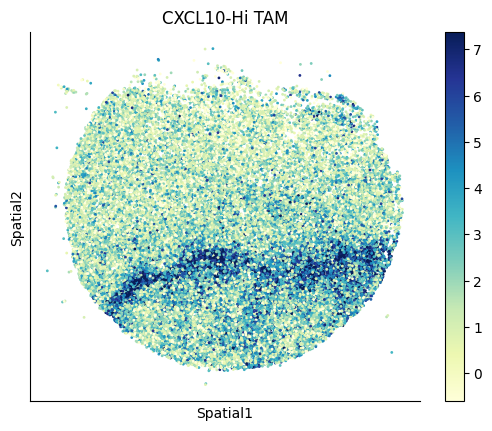

Puck_220408_13


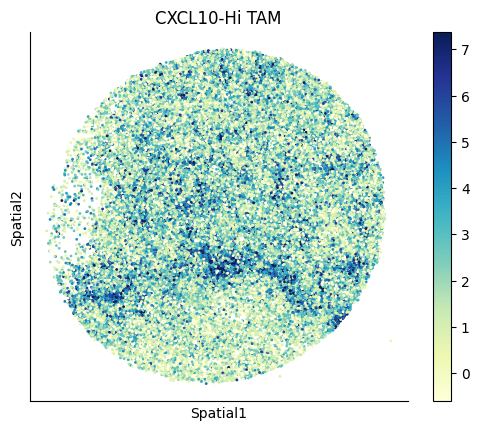

Puck_220408_15


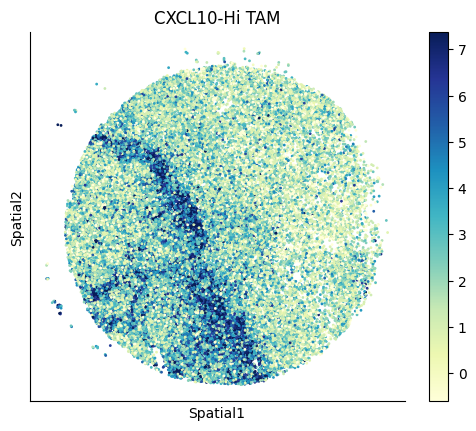

Puck_200727_09


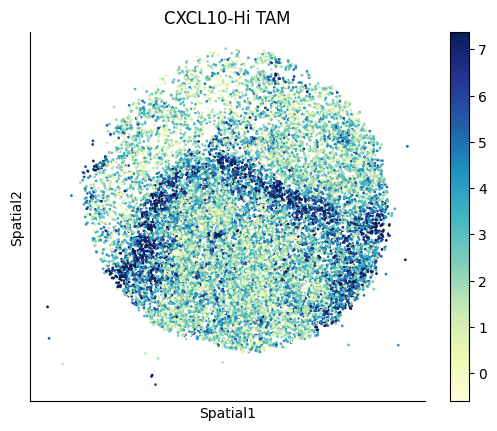

Puck_200727_10


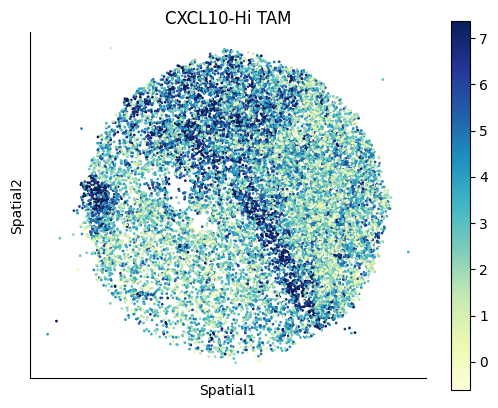

Puck_200727_08


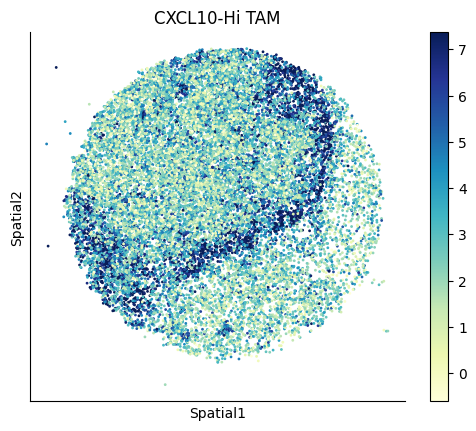

Puck_220408_14


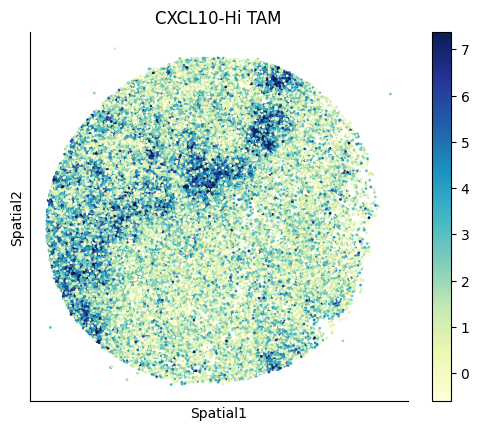

In [44]:
plot_signature_scores(adata, coords_obsm_key='spatial', signatures=['CXCL10-Hi TAM'], s=1, vmin='p5', vmax='p95', cmap='YlGnBu', sample_specific=True, colorbar=True, save=True, show=True)

## Quantification of macrophage subset signature scores across spatial regions

In [21]:
scores_df = adata.obsm["vision_signatures"].copy()
signatures = scores_df.columns
scores_df = pd.DataFrame(zscore(scores_df), index=scores_df.index, columns=scores_df.columns)

In [22]:
scores_df = pd.concat([scores_df, adata.obs[['sample', 'top_module']]], axis=1).dropna()

In [23]:
scores_df_grouped = scores_df.groupby(["sample", "top_module"])[signatures].mean().reset_index()

In [24]:
scores_df_melted = scores_df_grouped.melt(id_vars=["sample", "top_module"], var_name="signature", value_name="mean_abundance")

In [36]:
palette = {
    'CXCL10-Hi TAM': "#ABDDA4",
    'VSIR-Hi TAM': "#C7EAE5",
    'GPNMB-Hi TAM': "#DFC27D",
    'FOLR2-Hi TAM': "#FC9272",
    'Cycling TAM': "#3288BD",
}

In [37]:
', '.join(palette.keys())

'CXCL10-Hi TAM, VSIR-Hi TAM, GPNMB-Hi TAM, FOLR2-Hi TAM, Cycling TAM'

In [38]:
scores_df_melted['signature'] = scores_df_melted['signature'].astype('category')
scores_df_melted['signature'] = scores_df_melted['signature'].cat.reorder_categories(list(palette.keys()))

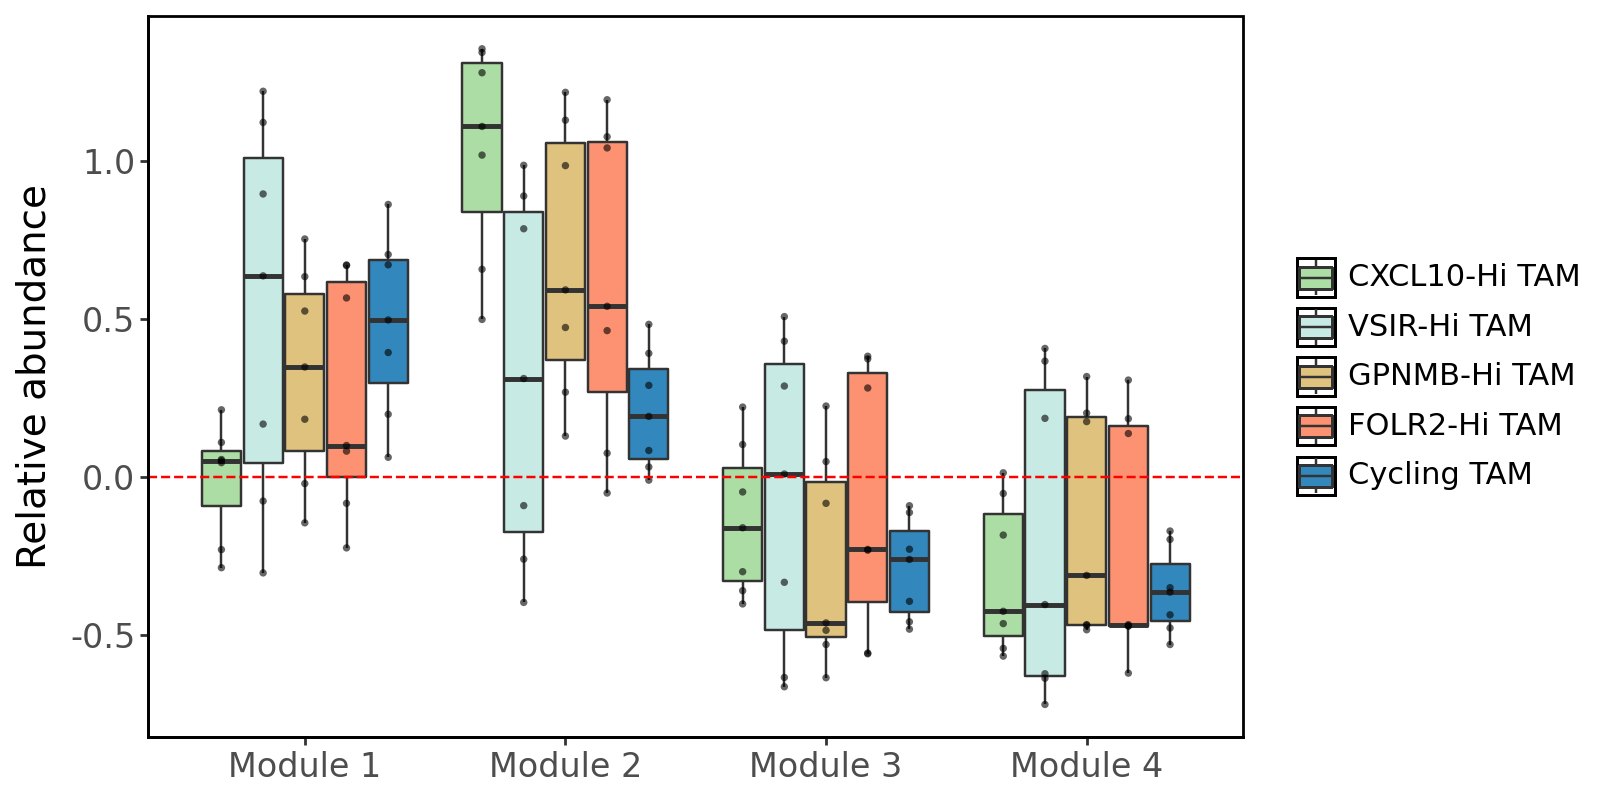

In [39]:
fig = (ggplot(data=scores_df_melted, mapping=aes(x='top_module', y='mean_abundance', fill='signature')) 
        + geom_boxplot(outlier_shape="", position=position_dodge(width=0.8))
        + geom_point(aes(group="signature"), color="", fill='black', position=position_dodge(width=0.8), alpha=0.6, size=1)  # Black dots
        + geom_hline(yintercept=0, linetype="dashed", color="red")
        + scale_fill_manual(values=palette)
        + theme_classic()
        + theme(plot_title = element_text(hjust = 0.5,
                                margin={"t": 0, "b": 0, "l": 10, "r": 0},
                                size = 9),
        legend_title = element_blank(),
        legend_text = element_text(size = 11),
        strip_text = element_text(size = 11),
        axis_title_x = element_blank(),
        axis_title_y = element_text(size = 14),
        axis_text_x = element_text(size = 12, rotation=0),
        # axis_text_x = element_blank(),
        axis_text_y = element_text(margin={"t": 0, "b": 0, "l": 0, "r": 2}, size = 12),
        panel_grid_major = element_blank(),
        panel_grid_minor = element_blank(),
        panel_border = element_rect(color='black'),
        panel_background = element_rect(colour = "black",
                                        linewidth = 1),
        figure_size=(8, 4)) 
        + labs(x="", y="Relative abundance"))

fig.show()
fig.save(os.path.join(PLOTS_PATH, 'm_mac_subset_rel_abundance_bar_plot.svg'))